# Building a Tiny Tensor Autograd Engine

A `Tensor` is the building block for any computation graph:

- a `Tensor` object stores `data`, `grad`, `requires_grad`, `grad_fn`, and `_parents`;
- `backward()` builds a topological sorting and traverses the computation graph backwards

## 0. Overview

Autograd records a computation as a directed acyclic graph a.k.a. **gradient tape**. Each node is a `Tensor`. Edges point from inputs to the tensor produced by an operation.

During the **forward pass**, values flow from inputs to output. During the **backward pass**, gradients flow from the final scalar output back to every tensor that requested gradients.



For a scalar final output `loss`, `loss.grad` starts as `1`, because:

$$
\frac{\partial \text{loss}}{\partial \text{loss}} = 1
$$

**Chain rule** is used at every node to backpropagate gradients.


## 1. Imports

We only need NumPy for the engine. Graphviz is used later for visualization, and PyTorch is optional for checking our answers against a mature autograd implementation.


In [63]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 2. Broadcasting during backpropagation

NumPy broadcasting lets us write operations such as:

```python
A.shape == (2, 3)
b.shape == (1, 3)
A + b       # b is copied across the first axis
```

The forward pass is convenient, but the backward pass must reverse that implicit copying. If a value was broadcast from shape `(1, 3)` to `(2, 3)`, its gradient must be summed back to shape `(1, 3)`.



The helper below receives a gradient with the **output shape** and reduces it back to the **original input shape**.


In [64]:
def _unbroadcast(grad, shape):
    """Sum a broadcasted gradient back to an original tensor shape.

    Parameters
    ----------
    grad:
        The gradient produced at the output of an operation.
    shape:
        The original shape of the operand before NumPy broadcasting.
    """
    # Extra leading axes were created by broadcasting; remove them.
    while len(grad.shape) > len(shape):
        grad = np.sum(grad, axis=0)

    # Axes with original size 1 were broadcast; sum over those axes.
    for i, dim in enumerate(shape):
        if dim == 1:
            grad = np.sum(grad, axis=i, keepdims=True)

    return grad

## 3. The `Tensor`

In [65]:
class Tensor:
    def __init__(
        self,
        data,
        dtype=np.float32,
        requires_grad=False,
    ):
        self.data = np.array(data, dtype=dtype)
        self.requires_grad = requires_grad

        if self.requires_grad:
            self.grad = np.zeros_like(self.data, dtype=dtype)
        else:
            self.grad = None

        self.grad_fn = None
        self._parents = []

    def __repr__(self):
        if self.grad_fn is not None:
            return f"Tensor({self.data}, grad_fn=<{self.grad_fn.__name__}>)"

        return f"Tensor({self.data}, requires_grad={self.requires_grad})"

    @property
    def shape(self):
        return self.data.shape

    def detach(self):
        return Tensor(
            self.data.copy(),
            dtype=self.data.dtype,
            requires_grad=False,
        )

    def zero_grad(self):
        if self.requires_grad:
            self.grad = np.zeros_like(self.data, dtype=self.data.dtype)

    def _ensure_tensor(self, other):
        if isinstance(other, Tensor):
            return other

        return Tensor(
            other,
            dtype=self.data.dtype,
            requires_grad=False,
        )

In [66]:
a = Tensor([[1.0, 2.0, 3.0]], requires_grad=True)
print(a)
print("data shape:", a.shape)
print("grad:", a.grad)

Tensor([[1. 2. 3.]], requires_grad=True)
data shape: (1, 3)
grad: [[0. 0. 0.]]


## 4. Add operations to `Tensor`

Every operation follows the same pattern:

1. convert non-`Tensor` inputs with `_ensure_tensor`;
2. compute the output data using NumPy;
3. set `requires_grad=True` if at least one parent requires gradients;
4. if gradients are required, save the backward rule and the parent list.

In a production class we would write these directly as methods. In this tutorial, we attach them one block at a time so students can focus on one operation at a time.


In [67]:
def tensor_T(self):
    out = Tensor(
        self.data.T,
        dtype=self.data.dtype,
        requires_grad=self.requires_grad,
    )

    if out.requires_grad:
        out.grad_fn = TransposeBackward
        out._parents = [self]

    return out


Tensor.T = property(tensor_T)

In [68]:
def tensor_dot(self, other):
    other = self._ensure_tensor(other)

    out = Tensor(
        self.data.dot(other.data),
        dtype=self.data.dtype,
        requires_grad=self.requires_grad or other.requires_grad,
    )

    if out.requires_grad:
        out.grad_fn = DotBackward
        out._parents = [self, other]

    return out


Tensor.dot = tensor_dot

In [69]:
def tensor_add(self, other):
    other = self._ensure_tensor(other)

    out = Tensor(
        self.data + other.data,
        dtype=self.data.dtype,
        requires_grad=self.requires_grad or other.requires_grad,
    )

    if out.requires_grad:
        out.grad_fn = AddBackward
        out._parents = [self, other]

    return out


def tensor_radd(self, other):
    other = self._ensure_tensor(other)
    return other + self


Tensor.__add__ = tensor_add
Tensor.__radd__ = tensor_radd

In [70]:
def tensor_sub(self, other):
    other = self._ensure_tensor(other)

    out = Tensor(
        self.data - other.data,
        dtype=self.data.dtype,
        requires_grad=self.requires_grad or other.requires_grad,
    )

    if out.requires_grad:
        out.grad_fn = SubBackward
        out._parents = [self, other]

    return out


def tensor_rsub(self, other):
    other = self._ensure_tensor(other)
    return other - self


Tensor.__sub__ = tensor_sub
Tensor.__rsub__ = tensor_rsub

In [71]:
def tensor_neg(self):
    out = Tensor(
        -self.data,
        dtype=self.data.dtype,
        requires_grad=self.requires_grad,
    )

    if out.requires_grad:
        out.grad_fn = NegBackward
        out._parents = [self]

    return out


Tensor.__neg__ = tensor_neg

## 5. Local backward rules

Each operation is responsible for exactly one local chain-rule step. In this implementation, we store that rule in a function such as `AddBackward`, `DotBackward`, or `TransposeBackward`.

Two details matter:

1. We use `+=`, not `=`, because the same tensor can feed multiple later operations. Gradients from all downstream paths must accumulate.
2. For addition and subtraction, we call `_unbroadcast` before adding to a parent gradient.



The matrix-dot rule is the most important one:

$$
Y = A B
$$

$$
\frac{\partial L}{\partial A} = \frac{\partial L}{\partial Y}B^T
\qquad
\frac{\partial L}{\partial B} = A^T\frac{\partial L}{\partial Y}
$$


### Dot / Matrix Multiplication

$$
Y = AB
$$

$$
\frac{\partial L}{\partial A}
=
\frac{\partial L}{\partial Y} B^T
$$

$$
\frac{\partial L}{\partial B}
=
A^T \frac{\partial L}{\partial Y}
$$

---

For example:
```python
def DotBackward(nodes, out):
    a, b = nodes

    if a.requires_grad:
        a.grad += out.grad.dot(b.data.T)

    if b.requires_grad:
        b.grad += a.data.T.dot(out.grad)
```


### Transpose

$$
Y = X^T
$$

$$
\frac{\partial L}{\partial X}
=
\left(
\frac{\partial L}{\partial Y}
\right)^T
$$

---

### Negation

$$
Y = -X
$$

$$
\frac{\partial L}{\partial X}
=
-\frac{\partial L}{\partial Y}
$$

---

### Addition

$$
Y = A + B
$$

$$
\frac{\partial L}{\partial A}
=
\frac{\partial L}{\partial Y}
$$

$$
\frac{\partial L}{\partial B}
=
\frac{\partial L}{\partial Y}
$$

With broadcasting:

$$
\frac{\partial L}{\partial A}
=
\operatorname{unbroadcast}
\left(
\frac{\partial L}{\partial Y},
\operatorname{shape}(A)
\right)
$$

$$
\frac{\partial L}{\partial B}
=
\operatorname{unbroadcast}
\left(
\frac{\partial L}{\partial Y},
\operatorname{shape}(B)
\right)
$$

---

### Subtraction

$$
Y = A - B
$$

$$
\frac{\partial L}{\partial A}
=
\frac{\partial L}{\partial Y}
$$

$$
\frac{\partial L}{\partial B}
=
-\frac{\partial L}{\partial Y}
$$

With broadcasting:

$$
\frac{\partial L}{\partial A}
=
\operatorname{unbroadcast}
\left(
\frac{\partial L}{\partial Y},
\operatorname{shape}(A)
\right)
$$

$$
\frac{\partial L}{\partial B}
=
\operatorname{unbroadcast}
\left(
-\frac{\partial L}{\partial Y},
\operatorname{shape}(B)
\right)
$$

In [72]:
def DotBackward(nodes, out):
    a, b = nodes

    if a.requires_grad:
        a.grad += out.grad.dot(b.data.T)

    if b.requires_grad:
        b.grad += a.data.T.dot(out.grad)


def TransposeBackward(nodes, out):
    x = nodes[0]

    if x.requires_grad:
        x.grad += out.grad.T


def NegBackward(nodes, out):
    x = nodes[0]

    if x.requires_grad:
        x.grad -= out.grad

def AddBackward(nodes, out):
    a, b = nodes

    if a.requires_grad:
        a.grad += _unbroadcast(out.grad,a.shape)

    if b.requires_grad:
        b.grad += _unbroadcast(out.grad,b.shape)

def SubBackward(nodes, out):
    a, b = nodes

    if a.requires_grad:
        a.grad += _unbroadcast(out.grad,a.shape)

    if b.requires_grad:
        b.grad -= _unbroadcast(out.grad,b.shape)
    

## 6. Implement `backward()` with a topological sort

The backward pass must process the nodes in reverse order.

The algorithm is:

1. start from the final scalar tensor;
2. recursively visit parents before children;
3. seed the final tensor's gradient with ones;
4. walk the topological list in reverse;
5. call each node's `grad_fn` to pass gradients to its parents.

This implementation computes gradients only from a scalar output. For vector outputs, a full Jacobian would be needed.

In [73]:
def tensor_backward(self):
    if self.data.size != 1:
        raise Exception(
            "Cannot compute Jacobians. Make sure you backprop from a single-value tensor."
        )

    topo_order = []
    visited = set()

    def build_topo(node):
        if node in visited:
            return

        visited.add(node)

        if not node.requires_grad:
            return

        for parent in node._parents:
            build_topo(parent)

        topo_order.append(node)

    build_topo(self)

    self.grad = np.ones_like(self.data, dtype=self.data.dtype)

    for node in reversed(topo_order):
        if node.grad_fn is not None:
            node.grad_fn(node._parents, node)


Tensor.backward = tensor_backward

## 6. Visualize a computation graph

Understanding the code below is NOT relevant for this lab.

In [74]:
# !python -m pip install graphviz

In [75]:
try:
    from graphviz import Digraph
    from IPython.display import display
except Exception:
    Digraph = None
    display = print


def label(tensor, name):
    """Attach a human-readable label for graph drawings."""
    tensor._label = name
    return tensor


def trace(root):
    nodes, edges = set(), set()

    def build(node):
        if node not in nodes:
            nodes.add(node)
            for parent in node._parents:
                edges.add((parent, node))
                build(parent)

    build(root)
    return nodes, edges


def draw_graph(root, rankdir="LR"):
    if Digraph is None:
        print("Graphviz is not available in this environment.")
        return None

    dot = Digraph(format="svg", graph_attr={"rankdir": rankdir})
    dot.attr("node", fontname="Helvetica", fontsize="10")

    nodes, edges = trace(root)

    for node in nodes:
        node_id = str(id(node))
        label_name = getattr(node, "_label", "")
        grad_text = "None" if node.grad is None else np.array2string(node.grad, precision=3).replace("\n", " ")
        data_text = np.array2string(node.data, precision=3).replace("\n", " ")
        op_text = "" if node.grad_fn is None else node.grad_fn.__name__.replace("Backward", "")
        dot.node(
            node_id,
            label=f"{label_name}\ndata={data_text}\ngrad={grad_text}\nshape={node.data.shape}",
            shape="box",
        )

        if node.grad_fn is not None:
            op_id = node_id + "_op"
            dot.node(op_id, op_text, shape="ellipse")
            dot.edge(op_id, node_id)

    for parent, child in edges:
        child_op_id = str(id(child)) + "_op"
        dot.edge(str(id(parent)), child_op_id)

    return dot

#### Testing with a small example

In [76]:
x = Tensor([[1.0, 2.0]], requires_grad=True)
W = Tensor([[3.0], [4.0]], requires_grad=True)
b = Tensor([[5.0]], requires_grad=True)

loss = x.dot(W) + b
print(loss)
print("loss.data:", loss.data)

Tensor([[16.]], grad_fn=<AddBackward>)
loss.data: [[16.]]


In [77]:
loss.backward()

print("loss.data =", loss.data)
print("x.grad    =", x.grad)     # dloss/dx = W.T
print("W.grad    =", W.grad)     # dloss/dW = x.T
print("b.grad    =", b.grad)     # dloss/db = 1

display(draw_graph(loss))

loss.data = [[16.]]
x.grad    = [[3. 4.]]
W.grad    = [[1.]
 [2.]]
b.grad    = [[1.]]
Graphviz is not available in this environment.
None


#### Broadcasting example

In [78]:
A = Tensor(
    [[1.0, 2.0, 3.0],
     [4.0, 5.0, 6.0]],
    requires_grad=True,
)
B = Tensor([[10.0, 20.0, 30.0]], requires_grad=True)

ones_left = Tensor(np.ones((1, 2), dtype=np.float32))
ones_right = Tensor(np.ones((3, 1), dtype=np.float32))

broadcast_loss = ones_left.dot((A + B).dot(ones_right))
label(A, "A")
label(B, "B")
label(broadcast_loss, "sum(A+B)")

broadcast_loss.backward()

print("broadcast_loss.data =", broadcast_loss.data)
print("A.grad =")
print(A.grad)
print("B.grad =")
print(B.grad)

display(draw_graph(broadcast_loss))

broadcast_loss.data = [[141.]]
A.grad =
[[1. 1. 1.]
 [1. 1. 1.]]
B.grad =
[[2. 2. 2.]]
Graphviz is not available in this environment.
None


## 7. Testing the implementation

We will test if the gradients were ok by comparing against pytorch. Use the command below to install pytorch.

Unserstanding the code in this section is NOT relevant for the lab.

In [79]:
try:
    import torch
except Exception:
    torch = None


def make_torch(x):
    return torch.tensor(x, dtype=torch.float32, requires_grad=True)


def assert_close(name, actual, expected, atol=1e-6):
    ok = np.allclose(actual, expected, atol=atol)

    print(f"{name}: {'PASS' if ok else 'FAIL'}")

    if not ok:
        print("actual:")
        print(actual)
        print("expected:")
        print(expected)

    return ok


def compare_with_torch(name, tensor_fn, torch_fn, arrays):
    if torch is None:
        print(f"Skipping {name}: PyTorch is not installed.")
        return None

    print(f"\n=== {name} ===")

    xs = [Tensor(a, requires_grad=True) for a in arrays]
    ts = [make_torch(a) for a in arrays]

    y = tensor_fn(*xs)
    yt = torch_fn(*ts)

    y.backward()
    yt.backward()

    forward_ok = assert_close("forward", y.data, yt.detach().numpy())

    all_ok = forward_ok

    for i, (x_item, t_item) in enumerate(zip(xs, ts)):
        ok = assert_close(
            f"grad[{i}]",
            x_item.grad,
            t_item.grad.detach().numpy(),
        )
        all_ok = all_ok and ok

    return all_ok

In [80]:
A_np = np.array(
    [[1.0, 2.0, 3.0],
     [4.0, 5.0, 6.0]],
    dtype=np.float32,
)

B_np = np.array(
    [[10.0, 20.0, 30.0]],
    dtype=np.float32,
)

C_np = np.array(
    [[1.0, 2.0],
     [3.0, 4.0],
     [5.0, 6.0]],
    dtype=np.float32,
)

D_np = np.array(
    [[0.5, -1.0],
     [2.0,  3.0]],
    dtype=np.float32,
)


compare_with_torch(
    "add broadcast",
    lambda a, b: Tensor(np.ones((1, 2), np.float32)).dot(
        (a + b).dot(np.ones((3, 1), np.float32))
    ),
    lambda a, b: torch.ones(1, 2) @ ((a + b) @ torch.ones(3, 1)),
    [A_np, B_np],
)


compare_with_torch(
    "sub broadcast",
    lambda a, b: Tensor(np.ones((1, 2), np.float32)).dot(
        (a - b).dot(np.ones((3, 1), np.float32))
    ),
    lambda a, b: torch.ones(1, 2) @ ((a - b) @ torch.ones(3, 1)),
    [A_np, B_np],
)


compare_with_torch(
    "reverse sub",
    lambda a: Tensor(np.ones((1, 2), np.float32)).dot(
        (100.0 - a).dot(np.ones((3, 1), np.float32))
    ),
    lambda a: torch.ones(1, 2) @ ((100.0 - a) @ torch.ones(3, 1)),
    [A_np],
)


compare_with_torch(
    "neg",
    lambda a: Tensor(np.ones((1, 2), np.float32)).dot(
        (-a).dot(np.ones((3, 1), np.float32))
    ),
    lambda a: torch.ones(1, 2) @ ((-a) @ torch.ones(3, 1)),
    [A_np],
)


compare_with_torch(
    "transpose",
    lambda a: Tensor(np.ones((1, 3), np.float32)).dot(
        a.T.dot(np.ones((2, 1), np.float32))
    ),
    lambda a: torch.ones(1, 3) @ (a.T @ torch.ones(2, 1)),
    [A_np],
)


compare_with_torch(
    "dot",
    lambda a, c, d: Tensor(np.ones((1, 2), np.float32)).dot(
        a.dot(c).dot(d).dot(np.ones((2, 1), np.float32))
    ),
    lambda a, c, d: torch.ones(1, 2) @ (
        a @ c @ d @ torch.ones(2, 1)
    ),
    [A_np, C_np, D_np],
)


=== add broadcast ===
forward: PASS
grad[0]: PASS
grad[1]: PASS

=== sub broadcast ===
forward: PASS
grad[0]: PASS
grad[1]: PASS

=== reverse sub ===
forward: PASS
grad[0]: PASS

=== neg ===
forward: PASS
grad[0]: PASS

=== transpose ===
forward: PASS
grad[0]: PASS

=== dot ===
forward: PASS
grad[0]: PASS
grad[1]: PASS
grad[2]: PASS


True

### Generating data
We will try to solve a mock classification problem. We'll generate random data that follows a pattern and have the model learn the distribution

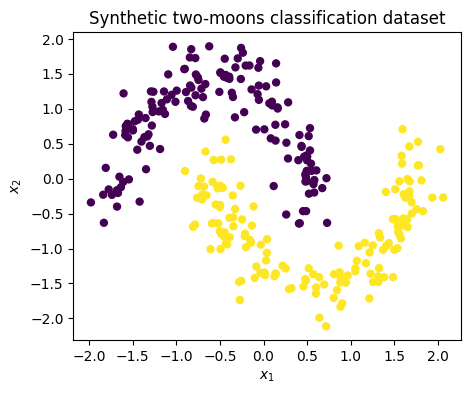

X shape: (300, 2)
y shape: (300, 1)


In [81]:
def make_two_moons_np(n_samples=300, noise=0.10, seed=42):
    rng = np.random.default_rng(seed)

    n_outer = n_samples // 2
    n_inner = n_samples - n_outer

    theta_outer = rng.uniform(0.0, np.pi, n_outer)
    theta_inner = rng.uniform(0.0, np.pi, n_inner)

    outer = np.c_[
        np.cos(theta_outer),
        np.sin(theta_outer),
    ]

    inner = np.c_[
        1.0 - np.cos(theta_inner),
        0.5 - np.sin(theta_inner),
    ]

    X = np.vstack([outer, inner]).astype(np.float32)
    y = np.hstack([
        np.zeros(n_outer),
        np.ones(n_inner),
    ]).astype(np.float32)

    X += rng.normal(
        loc=0.0,
        scale=noise,
        size=X.shape,
    ).astype(np.float32)

    permutation = rng.permutation(n_samples)
    X = X[permutation]
    y = y[permutation]

    X = (X - X.mean(axis=0, keepdims=True)) / (
        X.std(axis=0, keepdims=True) + 1e-7
    )

    y_signed = (2.0 * y - 1.0).reshape(-1, 1).astype(np.float32)

    return X, y, y_signed


X_np, y_np, y_signed_np = make_two_moons_np(
    n_samples=300,
    noise=0.12,
    seed=42,
)

plt.figure(figsize=(5, 4))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=25)
plt.title("Synthetic two-moons classification dataset")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

print("X shape:", X_np.shape)
print("y shape:", y_signed_np.shape)

### Implementing more operations :)

## Sigmoid activation

The sigmoid function maps any real number to a value between `0` and `1`.

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

For very negative inputs, the sigmoid is close to `0`.

For very positive inputs, the sigmoid is close to `1`.

This makes it useful for binary classification, where the model output can be interpreted as a probability:

$$
\hat{y} = \sigma(z)
$$

where:

$$
0 < \hat{y} < 1
$$

The derivative of sigmoid has a convenient form:

$$
\frac{d\sigma}{dx}
=
\sigma(x)(1 - \sigma(x))
$$

If the forward pass computes:

$$
Y = \sigma(X)
$$

then the backward pass receives:

$$
G = \frac{\partial L}{\partial Y}
$$

and computes:

$$
\frac{\partial L}{\partial X}
=
G \odot Y \odot (1 - Y)
$$

where $\odot$ means elementwise multiplication.

In code, `out.data` already stores $Y = \sigma(X)$, so the backward rule is:

```python
x.grad += out.grad * out.data * (1.0 - out.data)

In [89]:
def tensor_sigmoid(self):
    out = Tensor(
        1/(1+np.exp(-self.data)),
        dtype=self.data.dtype,
        requires_grad=self.requires_grad,
    )

    if out.requires_grad:
        out.grad_fn = SigmoidBackward
        out._parents = [self]

    return out

Tensor.sigmoid = tensor_sigmoid

In [90]:
def SigmoidBackward(nodes, out):
    x = nodes[0]
    x.grad += out.grad * out.data * (1.0 - out.data)

In [91]:
def tensor_log(self):
    out = Tensor(
        np.log(self.data),
        dtype=self.data.dtype,
        requires_grad=self.requires_grad,
    )

    if out.requires_grad:
        out.grad_fn = LogBackward
        out._parents = [self]

    return out

Tensor.log = tensor_log

In [92]:
def LogBackward(nodes, out):
    x = nodes[0]
    x.grad += out.grad * (1/out.data)

In [93]:
def tensor_mean(self):
    out = Tensor(
        np.mean(self.data),
        dtype=self.data.dtype,
        requires_grad=self.requires_grad,
    )

    if out.requires_grad:
        out.grad_fn = LogBackward
        out._parents = [self]

    return out

Tensor.mean = tensor_mean

In [94]:
def MeanBackward(nodes, out):
    x = nodes[0]
    x.grad += out.grad * 1/np.count(out.data)

In [95]:
def tensor_sum(self):
    pass

Tensor.sum = tensor_sum

In [96]:
def SumBackward(nodes, out):
    pass

In [97]:
def tensor_mul(self, other):
    pass


def tensor_rmul(self, other):
    pass


Tensor.__mul__ = tensor_mul
Tensor.__rmul__ = tensor_rmul

In [98]:
def MulBackward(nodes, out):
    pass

### Testing that everything works
You do NOT need to understand the cell bellow.

In [99]:
E_np = np.array(
    [[0.5, -1.0,  2.0],
     [1.5,  0.0, -0.5]],
    dtype=np.float32,
)

F_np = np.array(
    [[2.0, -3.0, 4.0]],
    dtype=np.float32,
)

G_np = np.array(
    [[0.5, 1.5, 2.5],
     [3.5, 4.5, 5.5]],
    dtype=np.float32,
)

Y_np = np.array(
    [[1.0],
     [0.0],
     [1.0],
     [0.0]],
    dtype=np.float32,
)

X_small_np = np.array(
    [[ 0.5, -1.0],
     [ 1.0,  2.0],
     [-1.5,  0.5],
     [ 2.0, -0.5]],
    dtype=np.float32,
)

W_small_np = np.array(
    [[ 0.5],
     [-1.0]],
    dtype=np.float32,
)

b_small_np = np.array(
    [[0.25]],
    dtype=np.float32,
)


compare_with_torch(
    "mul broadcast",
    lambda a, b: ((a * b).dot(np.ones((3, 1), np.float32))).mean(),
    lambda a, b: ((a * b) @ torch.ones(3, 1)).mean(),
    [E_np, F_np],
)


compare_with_torch(
    "reverse mul scalar",
    lambda a: (3.0 * a).dot(np.ones((3, 1), np.float32)).mean(),
    lambda a: (3.0 * a) @ torch.ones(3, 1).mean()
    if False else ((3.0 * a) @ torch.ones(3, 1)).mean(),
    [E_np],
)


compare_with_torch(
    "sigmoid",
    lambda a: a.sigmoid().dot(np.ones((3, 1), np.float32)).mean(),
    lambda a: torch.sigmoid(a) @ torch.ones(3, 1).mean()
    if False else (torch.sigmoid(a) @ torch.ones(3, 1)).mean(),
    [E_np],
)


compare_with_torch(
    "log",
    lambda g: g.log().dot(np.ones((3, 1), np.float32)).mean(),
    lambda g: (torch.log(g) @ torch.ones(3, 1)).mean(),
    [G_np],
)


compare_with_torch(
    "mean",
    lambda a: a.mean(),
    lambda a: a.mean(),
    [E_np],
)


compare_with_torch(
    "log sigmoid",
    lambda a: a.sigmoid().log().mean(),
    lambda a: torch.log(torch.sigmoid(a)).mean(),
    [E_np],
)


=== mul broadcast ===


AttributeError: 'NoneType' object has no attribute 'dot'

### Training the model

In [ ]:
X = Tensor(X_np)
y = Tensor(y_np.reshape(-1,1))
X.shape,y.shape

In [ ]:
W1 = Tensor(np.random.randn(2,16),requires_grad=True)
b1 = Tensor(np.zeros(16,),requires_grad=True)
W2 = Tensor(np.random.randn(16,1),requires_grad=True)
b2 = Tensor(np.zeros(1,),requires_grad=True)

def model(x):
    z1 = x.dot(W1) + b1
    z1 = z1.sigmoid()

    z2 = z1.dot(W2) + b2
    z2 = z2.sigmoid()

    return z2

params = (W1,b1,W2,b2)

In [ ]:
LR = 0.1

In [ ]:
for epoch in range(2000):
    y_hat = model(X)

    loss = -(y * y_hat.log() + (1. - y) * (1. - y_hat).log()).mean()

    for p in params:
        p.zero_grad()
        
    loss.backward()

    for p in params:
        p.data = p.data - LR * p.grad

### Visualising the learned function

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def predict_proba_numpy(X_grid):
    return model(Tensor(X_grid)).data


x_min, x_max = X.data[:, 0].min() - 0.5, X.data[:, 0].max() + 0.5
y_min, y_max = X.data[:, 1].min() - 0.5, X.data[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)

grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_probs = predict_proba_numpy(grid_points)
zz = grid_probs.reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, zz, levels=30, alpha=0.6)
plt.colorbar(label="Predicted probability")
plt.contour(xx, yy, zz, levels=[0.5], linewidths=2)
plt.scatter(
    X.data[:, 0],
    X.data[:, 1],
    c=y.data.reshape(-1),
    edgecolors="k",
    s=35,
)

plt.title("Function learned by the sigmoid model")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()